<a href="https://colab.research.google.com/github/naz-picones/MO-IT128-DMP-A3107-Lucero-Picones-Ramos/blob/main/Refined%20MO_IT128_Homework_Project_Clustering_and_Segmentation_BSIT_A3107_Lucero%2CC_J%2C_Ramos%2C_M_G%2C_Picones%2CM_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import os, glob
import pandas as pd
import numpy as np

# Plots
import matplotlib.pyplot as plt

# Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Display
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [48]:
ZIP_PATH = None  # e.g., "MO-IT128-DMP-A3107-Lucero-Picones-Ramos-main.zip"

if ZIP_PATH is not None:
    from zipfile import ZipFile
    with ZipFile(ZIP_PATH, "r") as z:
        z.extractall("finmark_project")
    BASE_DIR = "finmark_project"
else:
    # If you uploaded CSVs directly, keep BASE_DIR as current folder.
    BASE_DIR = "."

print("BASE_DIR:", BASE_DIR)

BASE_DIR: .


In [49]:
def find_first(patterns, base_dir="."):
    for pat in patterns:
        hits = glob.glob(os.path.join(base_dir, "**", pat), recursive=True)
        if hits:
            # Prefer the shortest path (usually the most direct copy)
            hits = sorted(hits, key=lambda x: (len(x), x))
            return hits[0]
    return None

paths = {
    "transaction_aggregates": find_first(
        ["Transaction_Aggregates.csv", "*Transaction_Aggregates*.csv"],
        base_dir=BASE_DIR
    ),
    "customer_feedback_engineered": find_first(
        ["Customer_Feedback_Engineered.csv", "*Customer_Feedback_Engineered*.csv"],
        base_dir=BASE_DIR
    ),
    "transaction_engineered": find_first(
        ["Transaction_Engineered.csv", "*Transaction_Engineered*.csv"],
        base_dir=BASE_DIR
    ),
    "finmark_final": find_first(
        ["FinMark_Final.csv", "*FinMark_Final*.csv"],
        base_dir=BASE_DIR
    ),
}

paths

{'transaction_aggregates': './Transaction_Aggregates.csv',
 'customer_feedback_engineered': './Customer_Feedback_Engineered.csv',
 'transaction_engineered': None,
 'finmark_final': None}

In [50]:
def safe_read_csv(path):
    if path is None:
        return None
    return pd.read_csv(path)

df_tx_agg = safe_read_csv(paths["transaction_aggregates"])
df_fb = safe_read_csv(paths["customer_feedback_engineered"])
df_final = safe_read_csv(paths["finmark_final"])

print("Transaction_Aggregates:", None if df_tx_agg is None else df_tx_agg.shape)
print("Customer_Feedback_Engineered:", None if df_fb is None else df_fb.shape)
print("FinMark_Final:", None if df_final is None else df_final.shape)

Transaction_Aggregates: (993, 7)
Customer_Feedback_Engineered: (1000, 7)
FinMark_Final: None


In [51]:
if df_tx_agg is not None:
    display(df_tx_agg.head())
if df_fb is not None:
    display(df_fb.head())


,Customer_ID,Transaction_Count,Total_Amount,Avg_Amount,Std_Amount,Min_Amount,Max_Amount
0,1,6,16836.0,2806.0,2062.310646,156.0,4993.0
1,2,2,4907.0,2453.5,560.735677,2057.0,2850.0
2,3,1,1538.0,1538.0,0.000000,1538.0,1538.0
3,4,2,8295.0,4147.5,832.264681,3559.0,4736.0
4,5,5,14798.0,2959.6,1386.584040,1508.0,4878.0


,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,Satisfaction_Category,Comment_Length,Satisfaction_Recommendation_Gap
0,1,10.0,Very satisfied,9,High,14,1.0
1,2,3.0,Very satisfied,3,Low,14,0.0
2,3,10.0,Very satisfied,1,High,14,9.0
3,4,7.0,Needs improvement,4,Medium,17,3.0
4,5,8.0,Unsatisfactory,7,High,14,1.0


##Clustering table (customer-level)

In [52]:
# Build customer_profile from transaction aggregates + feedback engineered
if df_tx_agg is None and df_final is not None:
    # Fallback: create aggregates from FinMark_Final if needed
    tx = df_final.copy()
    if "Transaction_Amount" in tx.columns:
        tx["Transaction_Amount"] = pd.to_numeric(tx["Transaction_Amount"], errors="coerce")
    customer_profile = (
        tx.groupby("Customer_ID")["Transaction_Amount"]
          .agg(Transaction_Count="count",
               Total_Amount="sum",
               Avg_Amount="mean",
               Std_Amount="std",
               Min_Amount="min",
               Max_Amount="max")
          .reset_index()
    )
elif df_tx_agg is not None:
    customer_profile = df_tx_agg.copy()
else:
    raise ValueError("Could not find Transaction_Aggregates.csv or FinMark_Final.csv to build customer features.")

if df_fb is not None:
    customer_profile = customer_profile.merge(df_fb, on="Customer_ID", how="left")

print("Customer profile shape:", customer_profile.shape)
display(customer_profile.head())

Customer profile shape: (993, 13)


,Customer_ID,Transaction_Count,Total_Amount,Avg_Amount,Std_Amount,Min_Amount,Max_Amount,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,Satisfaction_Category,Comment_Length,Satisfaction_Recommendation_Gap
0,1,6,16836.0,2806.0,2062.310646,156.0,4993.0,10.0,Very satisfied,9,High,14,1.0
1,2,2,4907.0,2453.5,560.735677,2057.0,2850.0,3.0,Very satisfied,3,Low,14,0.0
2,3,1,1538.0,1538.0,0.000000,1538.0,1538.0,10.0,Very satisfied,1,High,14,9.0
3,4,2,8295.0,4147.5,832.264681,3559.0,4736.0,7.0,Needs improvement,4,Medium,17,3.0
4,5,5,14798.0,2959.6,1386.584040,1508.0,4878.0,8.0,Unsatisfactory,7,High,14,1.0


##Feature selection & cleaning


In [53]:
# Columns to ALWAYS exclude from clustering
EXCLUDE_COLS = {
    "Customer_ID", "Transaction_ID", "Product_ID",
    "Transaction_Date", "Feedback_Comments", "Comment", "Comments"
}

# Redundant features to remove
REDUNDANT_COLS = {"Std_Amount", "Min_Amount", "Max_Amount", "Avg_Amount"}

# Detect numeric columns
numeric_cols = customer_profile.select_dtypes(include=[np.number]).columns.tolist()

# Remove excluded + redundant
candidate_cols = [
    c for c in numeric_cols
    if c not in EXCLUDE_COLS and c not in REDUNDANT_COLS
]

# SELECT ONLY NON-REDUNDANT FEATURES
selected_features = []

# Core features
if "Total_Amount" in candidate_cols:
    selected_features.append("Total_Amount")

if "Transaction_Count" in candidate_cols:
    selected_features.append("Transaction_Count")

# Choose one feedback / engagement feature only
feedback_priority = [
    "Satisfaction_Score",
    "Feedback_Score",
    "Customer_Rating",
    "Engagement_Score",
    "Loyalty_Score"
]

for col in feedback_priority:
    if col in candidate_cols and col not in selected_features:
        selected_features.append(col)
        break

# Fallback if none of the preferred feedback columns exist
if len(selected_features) < 3:
    for col in candidate_cols:
        if col not in selected_features:
            selected_features.append(col)
            break

print("Final features used:", selected_features)

# Create feature matrix
X = customer_profile[selected_features].copy()

# Fill missing values
X = X.fillna(X.median(numeric_only=True))

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape)

Final features used: ['Total_Amount', 'Transaction_Count', 'Satisfaction_Score']
X shape: (993, 3)


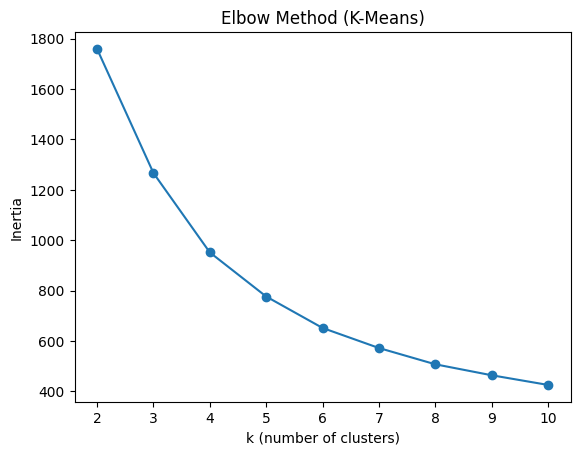

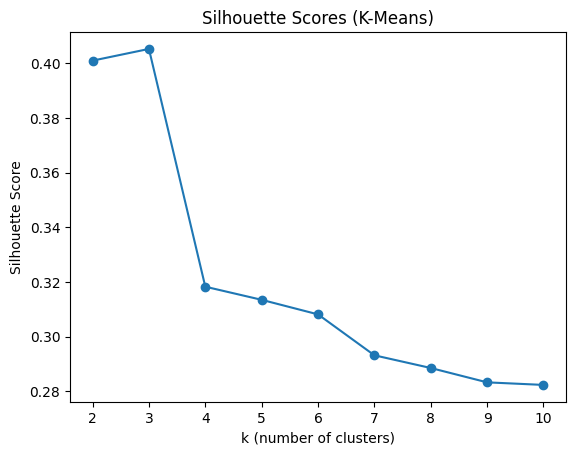

Best k by silhouette: 3
Best silhouette score: 0.405


In [54]:
ks = range(2, 11)
inertia = []
silhouettes = []

for k in ks:
    model = KMeans(n_clusters=k, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Elbow
plt.figure()
plt.plot(list(ks), inertia, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method (K-Means)")
plt.show()

# Silhouette
plt.figure()
plt.plot(list(ks), silhouettes, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (K-Means)")
plt.show()

best_k = int(ks[int(np.argmax(silhouettes))])
best_silhouette = max(silhouettes)

print("Best k by silhouette:", best_k)
print("Best silhouette score:", round(best_silhouette, 3))


In [55]:
best_silhouette = max(silhouettes)
print("Best k by silhouette:", best_k)
print("Best silhouette score:", round(best_silhouette, 3))

print(
    f"The chosen number of clusters is k={best_k} because it produced "
    f"the highest silhouette score of {best_silhouette:.3f}. "
    "A higher silhouette score means the clusters are more distinct and "
    "customers within each cluster are more similar to each other."
)

Best k by silhouette: 3
Best silhouette score: 0.405
The chosen number of clusters is k=3 because it produced the highest silhouette score of 0.405. A higher silhouette score means the clusters are more distinct and customers within each cluster are more similar to each other.


## Fit K-Means and assign cluster labels

In [56]:
K = best_k  # change if you prefer a different k (e.g., 4 or 5)
kmeans = KMeans(n_clusters=K, n_init=10)
customer_profile["Cluster"] = kmeans.fit_predict(X_scaled)

customer_profile[["Customer_ID", "Cluster"]].head()


,Customer_ID,Cluster
0,1,0
1,2,1
2,3,1
3,4,1
4,5,0


##Cluster profiling (summary table)

In [57]:
cluster_summary = customer_profile.groupby("Cluster")[selected_features].mean().round(2)
cluster_counts = customer_profile["Cluster"].value_counts().sort_index()

display(cluster_summary)
print("\nCluster sizes:")
display(cluster_counts)

,Total_Amount,Transaction_Count,Satisfaction_Score
Cluster,,,
0,18469.07,7.08,5.56
1,8365.28,3.61,5.48
2,21716.67,6.00,56.00



Cluster sizes:


,count
Cluster,
0,402
1,588
2,3


##Clusters using PCA (2D)


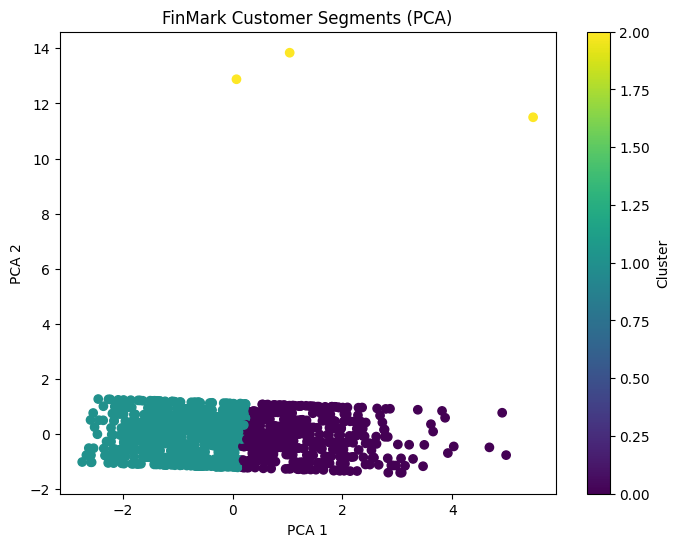

Explained variance by PCA components: [0.621 0.332]
PCA Loadings:


,PCA 1,PCA 2
Total_Amount,0.706,-0.037
Transaction_Count,0.705,-0.058
Satisfaction_Score,0.067,0.998


In [58]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(coords[:, 0], coords[:, 1], c=customer_profile["Cluster"], cmap='viridis')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("FinMark Customer Segments (PCA)")
plt.colorbar(label="Cluster")
plt.show()

print("Explained variance by PCA components:", pca.explained_variance_ratio_.round(3))

# ✅ FIXED
loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=["PCA 1", "PCA 2"]
)

print("PCA Loadings:")
display(loadings.round(3))

In [59]:
# Create descriptive cluster names based on spending and frequency
cluster_names = {}

for cl in cluster_summary.index:
    spend = cluster_summary.loc[cl, "Total_Amount"] if "Total_Amount" in cluster_summary.columns else 0
    freq = cluster_summary.loc[cl, "Transaction_Count"] if "Transaction_Count" in cluster_summary.columns else 0

    if spend == cluster_summary["Total_Amount"].max() and freq == cluster_summary["Transaction_Count"].max():
        cluster_names[cl] = "High-Value Frequent Customers"
    elif spend >= cluster_summary["Total_Amount"].median():
        cluster_names[cl] = "Moderate-Value Customers"
    else:
        cluster_names[cl] = "Low-Value Occasional Customers"

customer_profile["Cluster_Name"] = customer_profile["Cluster"].map(cluster_names)

cluster_summary_named = customer_profile.groupby("Cluster_Name")[selected_features].mean().round(2)
cluster_counts_named = customer_profile["Cluster_Name"].value_counts()

print("Cluster names:")
print(cluster_names)

display(cluster_summary_named)
print("\nCluster sizes:")
display(cluster_counts_named)

Cluster names:
{0: 'Moderate-Value Customers', 1: 'Low-Value Occasional Customers', 2: 'Moderate-Value Customers'}


,Total_Amount,Transaction_Count,Satisfaction_Score
Cluster_Name,,,
Low-Value Occasional Customers,8365.28,3.61,5.48
Moderate-Value Customers,18493.12,7.08,5.94



Cluster sizes:


,count
Cluster_Name,
Low-Value Occasional Customers,588
Moderate-Value Customers,405


In [60]:
print("Customer Segment Descriptions:")

for cl, name in cluster_names.items():
    spend = cluster_summary.loc[cl, "Total_Amount"] if "Total_Amount" in cluster_summary.columns else None
    freq = cluster_summary.loc[cl, "Transaction_Count"] if "Transaction_Count" in cluster_summary.columns else None
    size = cluster_counts[cl]

    description = f"{name}: "

    if name == "High-Value Frequent Customers":
        description += (
            "These customers spend the most and purchase the most often. "
            "They are the most valuable segment and are likely loyal customers."
        )
    elif name == "Moderate-Value Customers":
        description += (
            "These customers show average spending and moderate purchase frequency. "
            "They have potential for upselling and retention strategies."
        )
    else:
        description += (
            "These customers spend less and buy less often. "
            "They may need promotions or engagement strategies to increase activity."
        )

    description += f" Cluster size = {size}."
    print("-", description)

Customer Segment Descriptions:
- Moderate-Value Customers: These customers show average spending and moderate purchase frequency. They have potential for upselling and retention strategies. Cluster size = 402.
- Low-Value Occasional Customers: These customers spend less and buy less often. They may need promotions or engagement strategies to increase activity. Cluster size = 588.
- Moderate-Value Customers: These customers show average spending and moderate purchase frequency. They have potential for upselling and retention strategies. Cluster size = 3.


In [61]:
# Auto-draft: rank clusters by spend and satisfaction (if columns exist)
summary = cluster_summary.copy()

spend_col = None
for c in ["Total_Amount", "Total_Spend", "Total_Transaction_Amount"]:
    if c in summary.columns:
        spend_col = c
        break

sat_col = "Satisfaction_Score" if "Satisfaction_Score" in summary.columns else None

if spend_col:
    spend_rank = summary[spend_col].rank(ascending=False, method="dense").astype(int)
else:
    spend_rank = pd.Series(index=summary.index, data=np.nan)

if sat_col:
    sat_rank = summary[sat_col].rank(ascending=False, method="dense").astype(int)
else:
    sat_rank = pd.Series(index=summary.index, data=np.nan)

lines = []
for cl in summary.index:
    line = f"Cluster {cl}: "
    if spend_col:
        line += f"{spend_col}={summary.loc[cl, spend_col]:.2f} (rank {spend_rank[cl]}), "
    if sat_col:
        line += f"{sat_col}={summary.loc[cl, sat_col]:.2f} (rank {sat_rank[cl]}), "
    line += f"size={cluster_counts[cl]}"
    lines.append(line)

print("DRAFT NOTES (edit these into your write-up):")
for l in lines:
    print("-", l)

DRAFT NOTES (edit these into your write-up):
- Cluster 0: Total_Amount=18469.07 (rank 2), Satisfaction_Score=5.56 (rank 2), size=402
- Cluster 1: Total_Amount=8365.28 (rank 3), Satisfaction_Score=5.48 (rank 3), size=588
- Cluster 2: Total_Amount=21716.67 (rank 1), Satisfaction_Score=56.00 (rank 1), size=3
